In [ ]:
# Import library
import tensorflow as tf # TensorFlow: build and train a model
print("TensorFlow version:", tf.__version__)

import numpy as np #numerical operations
import matplotlib.pyplot as plt #visualize img and graphics
import os #folders
# Metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, auc, roc_curve
#to use modelcheckpoint
from keras.callbacks import ModelCheckpoint
#others:
import pandas as pd

import keras
from keras import layers #to create layers of the model
print(keras.__version__)

import seaborn as sns
import json
import shutil

import sklearn
print(sklearn.__version__)

TensorFlow version: 2.20.0
3.13.2
1.6.1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#create folder structure for results history
BASE_PATH = "/content/drive/MyDrive/results10"
print(BASE_PATH) #if the path is correct

folders = [
    "models",
    "histories",
    "metrics",
    "plots/training",
    "plots/confusion_matrix",
    "plots/roc"
]

for f in folders:
    os.makedirs(os.path.join(BASE_PATH, f), exist_ok=True)


#check drive si correctly implemented
print(os.listdir("/content/drive/MyDrive"))
#check the path
print(os.listdir(BASE_PATH)) #if it exists

/content/drive/MyDrive/results10
['Colab Notebooks', 'kaggle', 'results5', 'results10', 'resultsResnetOPT1', 'resultsVgg16DensenetOPT1', 'GradCam']
['models', 'histories', 'metrics', 'plots']


In [ ]:
# dataset folders directions
TRAIN_DIR = "/content/drive/MyDrive/kaggle/train"
TEST_DIR  = "/content/drive/MyDrive/kaggle/test"


#upload dataset

#define img sizes and batch sizes
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 # 32= small batch ->indirectly helps against ovefitting

#train dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",          # takes labels from folders
    label_mode="binary",        # binary classification
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)
#test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

#check labels
class_names = train_ds.class_names
print("Class:", class_names)

Found 2637 files belonging to 2 classes.
Found 660 files belonging to 2 classes.
Class: ['benign', 'malignant']


Normalization & data augmentation

In [ ]:
#normalization to put all value in [0,1]
normalization_layer = layers.Rescaling(1./255)

#apply normalization to train and test dataset
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization_layer(x), y))



#define fz for data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])
#apply data augm
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

CREATE VALIDATION DATASET (from training dataset)

In [ ]:
#split validation = 20% of train dataset
train_size = int(0.8 * tf.data.experimental.cardinality(train_ds).numpy()) #define size of train = 0,8 of the tot train_img

train_ds_split = train_ds.take(train_size) #new train dataset= 0,8 original train dataset
val_ds_split   = train_ds.skip(train_size) #validation dataset= 0,2 original train dataset

BUILD MODEL:
1) takes a CNN pre-trained (vg16, ResNet, DenseNet)
2) removes the original classificator of the model
3) block weight pre-trained
4) add a new classificator and adapt the algoritm to binary problem (benign vs melanoma malignant)


In [ ]:
#build model
def build_model(model_name):

    if model_name == "vgg16": #famous CNN: easy but powerful
        base_model = keras.applications.VGG16(
            weights="imagenet", #uses weight already trained on millions images
            include_top=False, #delate the last layer of clasification
            input_shape=(224,224,3) #img 224*224 RGB (3 colors)
        )

    elif model_name == "resnet": #resnet uses skip connection (deeper)
        base_model = keras.applications.ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=(224,224,3)
        )

    elif model_name == "densenet": #more advanced: every layer connected to the following
        base_model = keras.applications.DenseNet121(
            weights="imagenet",
            include_top=False,
            input_shape=(224,224,3)
        )

    # Transfer learning (freeze of the firsts layers already trained)
    base_model.trainable = False

    #define of the imput imgs shapes: 224x224, RGB (3 colors)
    inputs = keras.Input(shape=(224,224,3))

    # oss. 'x' represent the input data in the model that changes step by step during the different passages of the model

    #!! IN THE PREVIOUS VERSION I APPLIED DATA AUG. HERE IN THE MODEL, BUT THIS CREATES PROBLEM IN SAVING THE MODEL

    x = base_model(inputs, training=False) #  l'immagine passa attraverso i modelli: vgg16/DenseNet/ResNet
    #training=false: use fix weights
    #training=true: update weights

    x = layers.GlobalAveragePooling2D()(x) #pooling layer: from 2D matrix to vector 512
    x = layers.Dense(128, activation="relu")(x) #classification layer
    x = layers.Dropout(0.5)(x) #to avoid overfitting

    outputs = layers.Dense(1, activation="sigmoid")(x) #sigmoid gives probability output [0,1]
    # ouput 0=benign, 1=melanoma malignant

    #build the funcion model that takes the imgs input and gives a probability of a class as an output
    model = keras.Model(inputs, outputs) #imput ->network(layer->layer->layer->) -> output

    #optimizer
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    #return model ready for training
    return model


TRAINING:
create a for cicle to train and compare all the 3 models in the same run.

Each cicle:
new model,
initial weights form ImageNet,
same final structure for all 3.

In [ ]:
EPOCHS = 10

history_dict = {}
results = {}

for name in ["vgg16", "resnet", "densenet"]:
    print(f"\nTraining {name}")

    model = build_model(name) #create the model: output= probability benign vs malignant

    # create folders on drive
    os.makedirs(os.path.join(BASE_PATH, "models"), exist_ok=True) #exist_ok=true: doesn't crush if folder already exists
    os.makedirs(os.path.join(BASE_PATH, "histories"), exist_ok=True)

    #chekpoint_path
    checkpoint_path = os.path.join(BASE_PATH, "models", f"{name}_best.keras")

    # checkpoint (salva solo il migliore modello)
    #oss. salva il modello solo quando la val_loss migliora, altrimenti potrei salvare anche se va in overfitting :/
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path, #where it save the model
        monitor="val_loss", #check loss of validation
        save_best_only=True, #saves only if it gets better
        mode="min",
        verbose=1 #stamp when saves
    )

    #TRAINING
    history = model.fit(
        train_ds_split,
        validation_data=val_ds_split,
        epochs=EPOCHS,
        callbacks=[checkpoint] #activate checkpoint (save only the best model)
    )

    #SAVE HISTORY
    history_path = os.path.join(BASE_PATH, "histories", f"{name}_history.json") #history path

    with open(history_path, "w") as f:
        json.dump(history.history, f, indent=4) #saves history on files:
                                                #vgg16_history.json,resnet_history.json, densenet_history.json
    #oss. in histoy.histoy there are: {"loss": [...],"accuracy": [...], "val_loss": [...], "val_accuracy": [...]}

    history_dict[name] = history.history # store in dictionary (useful for quick plotting)



Training vgg16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.6027 - loss: 0.6565 
Epoch 1: val_loss improved from None to 0.52261, saving model to /content/drive/MyDrive/results10/models/vgg16_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/results10/models/vgg16_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 1192s 18s/step - accuracy: 0.6615 - loss: 0.6151 - val_accuracy: 0.8095 - val_loss: 0.5226
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7612 - loss: 0.5282 
Epoch 2: val_loss improved from 0.52261 to 0.47313, saving model to /content/drive/MyDrive/results10/models/vgg16_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/results10/models/vgg16_best.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 1106s 17s/step - accuracy: 0.7637 - loss: 0.5152 - val_accuracy: 0.8000 - val_loss: 0.4731
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.7513 - loss: 0.4964 
Epoch 3: va

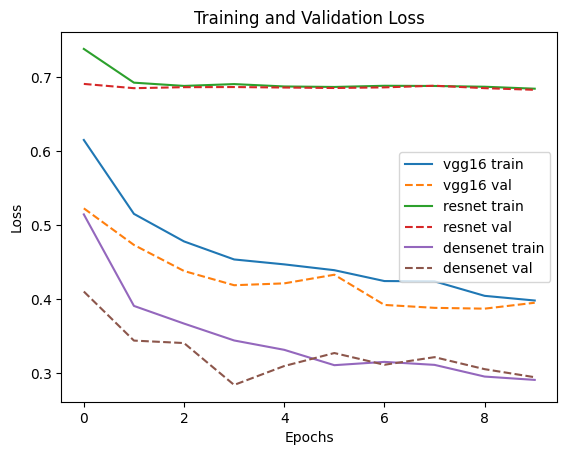

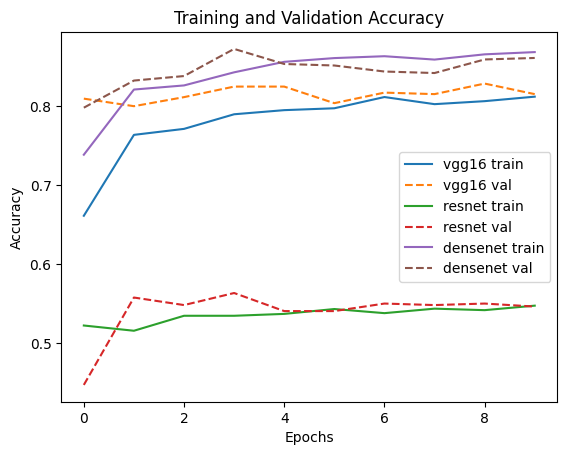

In [ ]:
models = ["vgg16", "resnet", "densenet"]
history_dict = {} #dictionary where i save all the historys

# load history from drive
for name in models:
    history_path = os.path.join(BASE_PATH, "histories", f"{name}_history.json") #build file path

#open file json, read it, convert it in python, save it in history_dict
    with open(history_path, "r") as f:
        history_dict[name] = json.load(f)


#PLOT LOSS
plt.figure() #create a new empty figure

for name in models:
    plt.plot(history_dict[name]["loss"], label=f"{name} train") #training loss: solid line
    plt.plot(history_dict[name]["val_loss"], linestyle="--", label=f"{name} val") #validation loss: dashed line

plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

#save in drive
loss_plot_path = os.path.join(BASE_PATH, "plots", "training", "loss_plot.png") #create path on drive
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight") #savefig: save graphic, dpi=300: high quality, "tight" delete empty points

plt.show() #show graphic
 #train loss ↓ =the model is learning
 # val loss ↓ = model generalise correctly
 #val loss ↑ while tain loss ↓ = overfitting


#ACCURACY PLOT
plt.figure()

for name in models:
    plt.plot(history_dict[name]["accuracy"], label=f"{name} train")
    plt.plot(history_dict[name]["val_accuracy"], linestyle="--", label=f"{name} val")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

#save in drive
acc_plot_path = os.path.join(BASE_PATH, "plots", "training", "accuracy_plot.png") #create path on drive
plt.savefig(acc_plot_path, dpi=300, bbox_inches="tight")

plt.show()
#accuracy ↑ = model is getting better
#gap train vs val = overfitting
#similar graphic curves = good generalization

TEST

In [ ]:

#build funcion model evaluate:
def evaluate_model(model, dataset):

    y_true = []
    y_pred = []

    # iterate over test dataset
    for x, y in dataset: #x=img, y=real label
        preds = model(x, training=False).numpy() #gives probability. training=false:no training
        #build lists:
        y_true.extend(y.numpy()) #true value
        y_pred.extend(preds.flatten()) #prediction

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # build the binary classification based on probability
    # threshold 0.5: <=0.5 benign
    y_bin = (y_pred > 0.5).astype(int)

    # confusion matrix
    cm = confusion_matrix(y_true, y_bin)
    tn, fp, fn, tp = cm.ravel()
    #TN= true negative at melanoma (true benign)
    #TP → true positive
    #FP → false positive at melanoma
    #FN → false negative (melanoma not diagnosticated!! most dangerous)

    # metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn) #how much the model is correct in general
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0 #!ability to find melanoma oss. if evida crash in edge cases
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0 ##ability to recognise benign
    f1 = 2 * tp / (2 * tp + fp + fn) #precision vs recall
    auc = roc_auc_score(y_true, y_pred)   # #global quality of the model. nb: use probabilities not classes

    return {
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1,
        "auc": auc
    }


# LOAD MODELS + TEST
models = ["vgg16", "resnet", "densenet"]
results = {}

for name in models:
    print(f"\nTesting {name}")

    # LOAD best model saved by ModelCheckpoint
    model_path = os.path.join(BASE_PATH, "models", f"{name}_best.keras") #path only of the best model saved
    model = keras.models.load_model(model_path) #load the best model in "model"

    # TEST: evaluate model
    metrics = evaluate_model(model, test_ds)
    results[name] = metrics #build the finally dictionary
    print(metrics)

# SAVE final results table
results_path = os.path.join(BASE_PATH, "metrics", "final_results.csv")

df = pd.DataFrame(results).T
df.to_csv(results_path) #saves the final tab: model | accuracy | sensitivity | specificity | f1 | auc

print("\nResults saved to:", results_path)


Testing vgg16
{'accuracy': np.float64(0.8257575757575758), 'sensitivity': np.float64(0.8933333333333333), 'specificity': np.float64(0.7694444444444445), 'f1': np.float64(0.8233486943164362), 'auc': np.float64(0.9072222222222223)}

Testing resnet
{'accuracy': np.float64(0.5454545454545454), 'sensitivity': np.float64(0.0), 'specificity': np.float64(1.0), 'f1': np.float64(0.0), 'auc': np.float64(0.7834722222222222)}

Testing densenet
{'accuracy': np.float64(0.8621212121212121), 'sensitivity': np.float64(0.8966666666666666), 'specificity': np.float64(0.8333333333333334), 'f1': np.float64(0.8553259141494436), 'auc': np.float64(0.9359537037037037)}

Results saved to: /content/drive/MyDrive/results10/metrics/final_results.csv


PLOT METRICS to compare performance

          accuracy  sensitivity  specificity        f1       auc
vgg16     0.825758     0.893333     0.769444  0.823349  0.907222
resnet    0.545455     0.000000     1.000000  0.000000  0.783472
densenet  0.862121     0.896667     0.833333  0.855326  0.935954


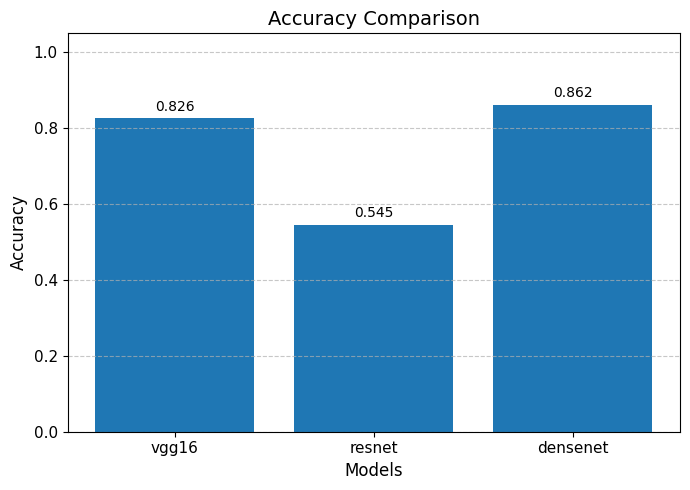

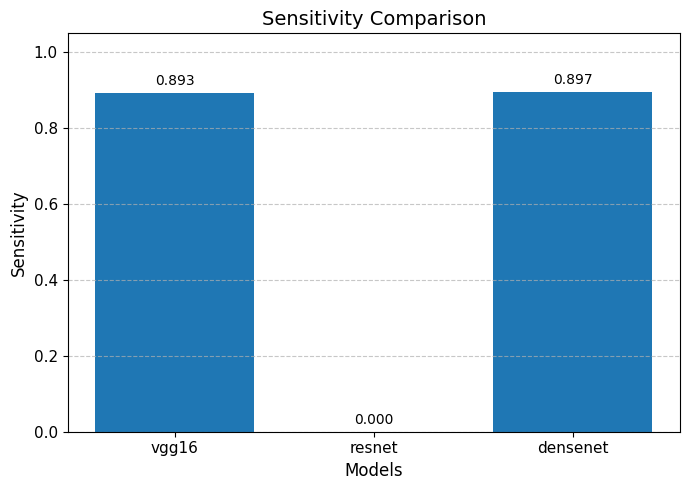

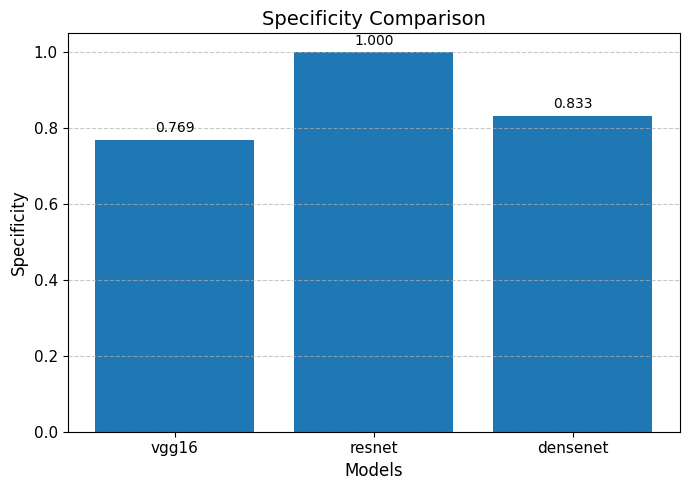

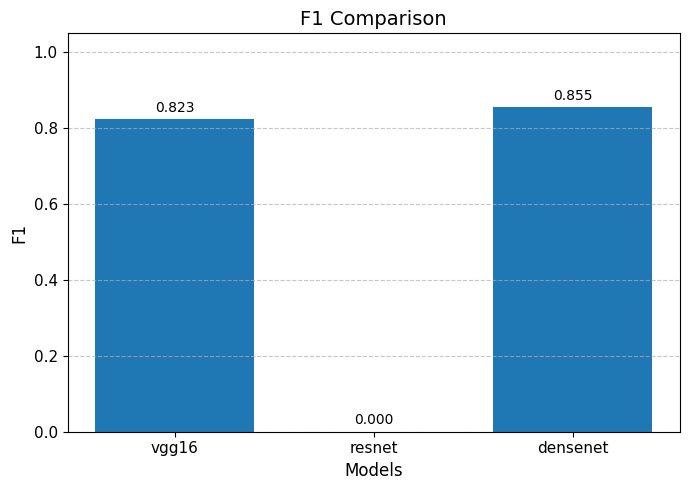

In [ ]:
# LOAD FINAL METRICS
results_path = os.path.join(BASE_PATH, "metrics", "final_results.csv")
df = pd.read_csv(results_path, index_col=0)
print(df)

# CREATE COMPARISON GRAPHS
metrics_list = ["accuracy", "sensitivity", "specificity", "f1"]
os.makedirs(os.path.join(BASE_PATH, "plots", "metrics"), exist_ok=True) #create path

for metric in metrics_list:

    # larger figure for thesis quality
    plt.figure(figsize=(7,5))

    # bar plot
    bars = plt.bar(df.index, df[metric])

    # titles and labels
    plt.title(f"{metric.capitalize()} Comparison", fontsize=14)
    plt.xlabel("Models", fontsize=12)
    plt.ylabel(metric.capitalize(), fontsize=12)

    # better axis scale
    plt.ylim(0, 1.05)

    # improve ticks
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)

    # values above bars
    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.02,
            f"{height:.3f}",
            ha="center",
            fontsize=10
        )

    # horizontal grid only
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # automatically fix layout problems
    plt.tight_layout()

    # save plot
    save_path = os.path.join(
        BASE_PATH,
        "plots",
        "metrics",
        f"{metric}_comparison.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

ROC CURVE GRAPHIC (false positive vs sensitivity)


Generating ROC for vgg16


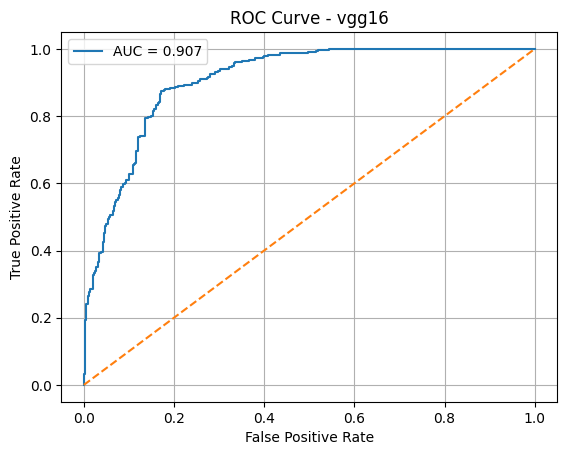


Generating ROC for resnet


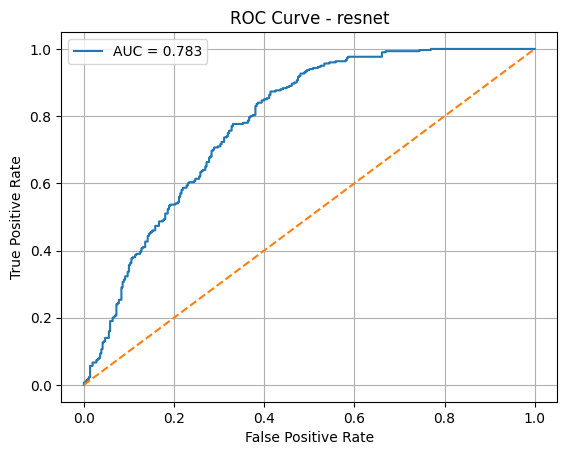


Generating ROC for densenet


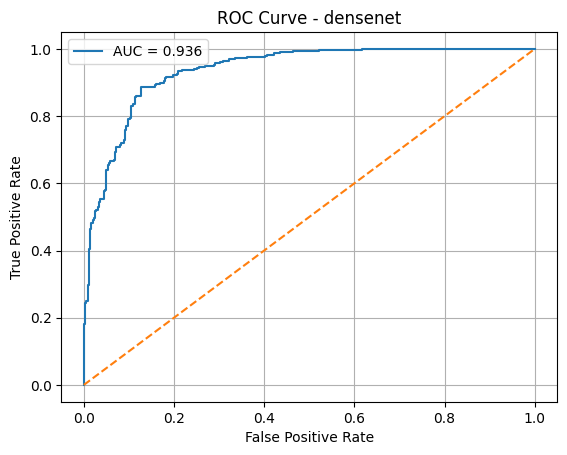

ROC data saved to: /content/drive/MyDrive/results10/metrics/roc_data.json


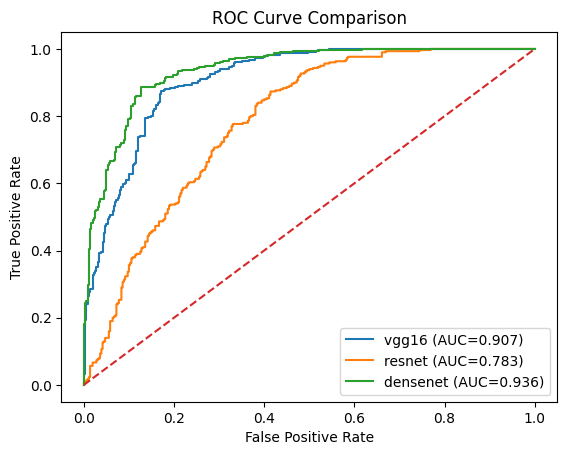

In [ ]:
# Diagonal line: causal model
# Line close to the left upper part: good model


#CREATE FUNCTION ROC CURVE that:
#takes model->test dataset-> create ROC-curve
def plot_roc(model, dataset, name):

    y_true = [] #real label
    y_pred = [] #probability

    # collect predictions
    for x, y in dataset:
        preds = model(x, training=False).numpy() #gives prbability [0,1]

        y_true.extend(y.numpy().flatten()) #list of true label
        y_pred.extend(preds.flatten()) #list of predictions

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # compute ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr) #global metric: 1=perfect, 0.5=random, <0.5=terrible
    #FPR=False Positive Rate
    #TPR= True Positive Rate/sensibility

    # PLOT
    plt.figure()

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}") #roc curve
    plt.plot([0, 1], [0, 1], linestyle="--") #random baseline

    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.legend()

    # SAVE img
    save_path = os.path.join(BASE_PATH, "plots", "roc", f"{name}.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return fpr, tpr, roc_auc

# LOOP MODELS + SAVE DATA FOR COMPARISON
models = ["vgg16", "resnet", "densenet"]
roc_data = {}

for name in models:
    print(f"\nGenerating ROC for {name}")

    model_path = os.path.join(BASE_PATH, "models", f"{name}_best.keras")
    model = keras.models.load_model(model_path)

    fpr, tpr, roc_auc = plot_roc(model, test_ds, name)

    roc_data[name] = { #raccolta dati per confronto
        "fpr": fpr.tolist(),   # impo conversation
        "tpr": tpr.tolist(),   # JSON dosen't support array numpy
        "auc": float(roc_auc)
    }

# SAVE ROC DATA
roc_data_path = os.path.join(BASE_PATH, "metrics", "roc_data.json")

with open(roc_data_path, "w") as f:
    json.dump(roc_data, f, indent=4)

print("ROC data saved to:", roc_data_path)


# COMPARISON PLOT (ALL MODELS)
plt.figure()

for name in models: #all curves in a single plot
    plt.plot(
        roc_data[name]["fpr"],
        roc_data[name]["tpr"],
        label=f"{name} (AUC={roc_data[name]['auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

comparison_path = os.path.join(BASE_PATH, "plots", "roc", "roc_comparison.png")
plt.savefig(comparison_path, dpi=300, bbox_inches="tight")

plt.show()

CONFUSION MATRIX GRAPHIC


Generating Confusion Matrix for vgg16


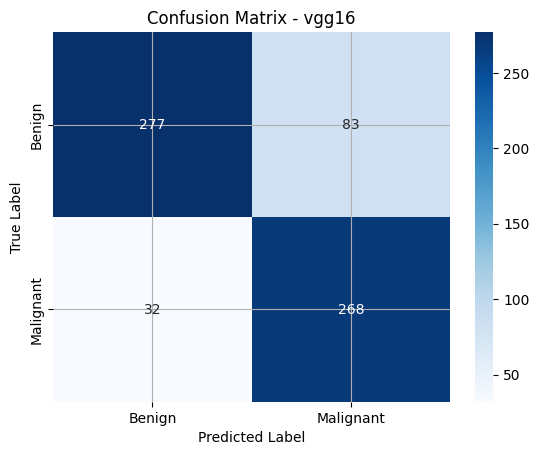


Generating Confusion Matrix for resnet


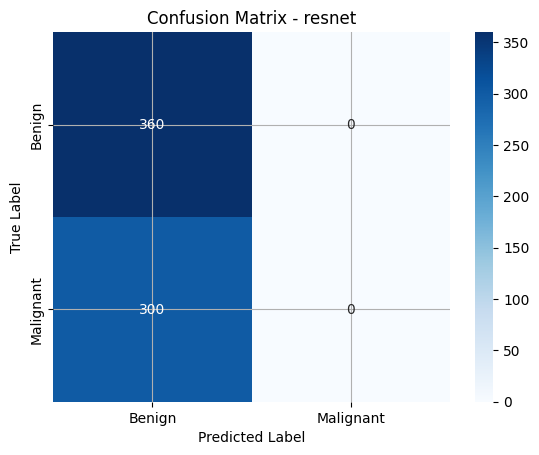


Generating Confusion Matrix for densenet


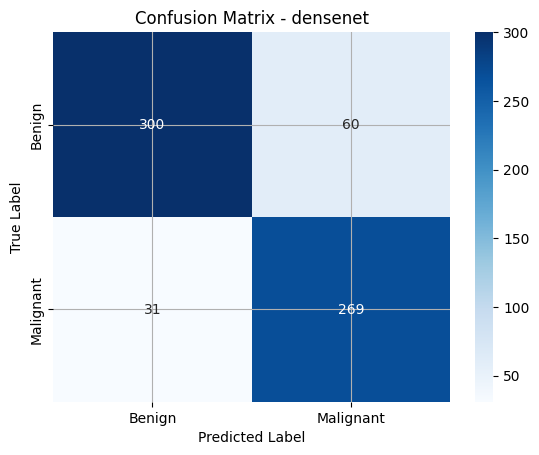

In [ ]:
#Confusion matrix graphic

#function for confusion matrix:
#take model->test>build confusion matrix->save it as img
def plot_cm(model, dataset, name):

    y_true = []
    y_pred = []

    # generate predictions
    for x, y in dataset: #x=img, y=true label
        preds = model(x, training=False).numpy() #give probability [0,1]

        y_true.extend(y.numpy()) #real label
        y_pred.extend(preds.flatten()) #probability

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # probability -> class predictionon
    y_bin = (y_pred > 0.5).astype(int)
    # confusion matrix (2x2 matrix)
    cm = confusion_matrix(y_true, y_bin)

    # PLOT
    plt.figure()

    sns.heatmap(
        cm,
        annot=True, #show numbers
        fmt="d", #formato intero
        cmap="Blues",#readables colors
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.grid(True)

    # SAVE to drive
    save_path = os.path.join(BASE_PATH, "plots", "confusion_matrix", f"{name}.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight") #300=high quality, "tight"=clean format

    plt.show()



# LOAD MODELS + CM
models = ["vgg16", "resnet", "densenet"]

#for all models:
#load best model->CM->save in drive
for name in models:
    print(f"\nGenerating Confusion Matrix for {name}")

    # load best model
    model_path = os.path.join(BASE_PATH, "models", f"{name}_best.keras")
    model = keras.models.load_model(model_path)

    # plot confusion matrix
    plot_cm(model, test_ds, name)

In [ ]:
# RESNET DEBUG
import tensorflow as tf
from tensorflow import keras


inputs = keras.Input(shape=(224,224,3))

backbone = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_tensor=inputs
)

print("\n last Resnet layers")

for layer in backbone.layers[-20:]:
    print(layer.name, layer.output.shape)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

=== LAST RESNET LAYERS ===
conv5_block2_1_conv (None, 7, 7, 512)
conv5_block2_1_bn (None, 7, 7, 512)
conv5_block2_1_relu (None, 7, 7, 512)
conv5_block2_2_conv (None, 7, 7, 512)
conv5_block2_2_bn (None, 7, 7, 512)
conv5_block2_2_relu (None, 7, 7, 512)
conv5_block2_3_conv (None, 7, 7, 2048)
conv5_block2_3_bn (None, 7, 7, 2048)
conv5_block2_add (None, 7, 7, 2048)
conv5_block2_out (None, 7, 7, 2048)
conv5_block3_1_conv (None, 7, 7, 512)
conv5_block3_1_bn (None, 7, 7, 512)
conv5_block3_1_relu (None, 7, 7, 512)
conv5_block3_2_conv (None, 7, 7, 512)
conv5_block3_2_bn (None, 7, 7, 512)
conv5_block3_2_relu (None, 7, 7, 512)
conv5_block3_3_conv (None, 7, 7, 2048)
conv5_block3_3_bn (None, 7, 7, 2048)
conv5_block3_add (None, 7, 7, 2048)
conv5_block3_out (None, 7, 7, 2048)


GRAD-CAM

In [ ]:
#import again if runtime disconnects
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow import keras

#define dimension
IMG_SIZE = (224, 224)
N_IMAGES_PER_CLASS = 10
THRESHOLD = 0.5

#define save path
SAVE_ROOT = "/content/drive/MyDrive/GradCam/OldModels"
os.makedirs(SAVE_ROOT, exist_ok=True)

print("Saving Grad-CAM results to:", SAVE_ROOT)

#build flat model:
def build_flat_model(model_name):
    inputs = keras.Input(shape=(224,224,3), name=f"{model_name}_input")

    if model_name == "vgg16":
        backbone = keras.applications.VGG16(
            weights="imagenet",
            include_top=False,
            input_tensor=inputs
        )
        last_conv_name = "block5_conv3"

    elif model_name == "resnet":
        backbone = keras.applications.ResNet50(
            weights="imagenet",
            include_top=False,
            input_tensor=inputs
        )
        last_conv_name = "conv5_block3_out"

    elif model_name == "densenet":
        backbone = keras.applications.DenseNet121(
            weights="imagenet",
            include_top=False,
            input_tensor=inputs
        )
        last_conv_name = "conv5_block16_2_conv"

    else:
        raise ValueError("Invalid model_name")

    #orignal non-optimized head
    x = backbone.output
    x = keras.layers.GlobalAveragePooling2D(name="head_gap")(x)
    x = keras.layers.Dense(128, activation="relu", name="head_dense" )(x)
    x = keras.layers.Dropout( 0.5,name="head_dropout")(x)

    outputs = keras.layers.Dense(1,activation="sigmoid",name="head_output" )(x)

    model = keras.Model(inputs, outputs,name=f"{model_name}_flat_model" )

    return model, last_conv_name

#copy trained models weight
def load_trained_weights_into_flat_model(model_name, weights_path):

    flat_model, last_conv_name = build_flat_model(model_name)
    trained = keras.models.load_model(weights_path)

    #get trained head layers
    trained_output = None
    trained_dense = None

    for layer in reversed(trained.layers):

        if trained_output is None and isinstance(layer, keras.layers.Dense):
            trained_output = layer
            continue

        if trained_dense is None and isinstance(layer, keras.layers.Dense):
            trained_dense = layer
            break

    if trained_dense is None or trained_output is None:
        raise RuntimeError(
            f"Could not identify trained head for {model_name}"
        )

    #flat model head
    flat_dense = flat_model.get_layer("head_dense")
    flat_output = flat_model.get_layer("head_output")

    #safety check
    def same_shapes(layer_a, layer_b):

        wa = [w.shape for w in layer_a.get_weights()]
        wb = [w.shape for w in layer_b.get_weights()]

        return wa == wb

    if not same_shapes(trained_dense, flat_dense):
        raise RuntimeError(
            f"Dense mismatch for {model_name}"
        )

    if not same_shapes(trained_output, flat_output):
        raise RuntimeError(
            f"Output mismatch for {model_name}"
        )

    #copy weights
    flat_dense.set_weights(
        trained_dense.get_weights()
    )

    flat_output.set_weights(
        trained_output.get_weights()
    )
    print(f"[OK] Loaded classifier head for {model_name}")

    return flat_model, last_conv_name



#Load first N images from each class
def load_first_n_from_class(test_dir, class_name, n=10):

    class_dir = os.path.join(test_dir, class_name)

    files = sorted([
        os.path.join(class_dir, f)
        for f in os.listdir(class_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))])[:n]

    imgs = []

    for f in files:
        img = keras.utils.load_img(f, target_size=IMG_SIZE)
        img = keras.utils.img_to_array(img).astype("float32") / 255.0
        imgs.append((img, f))
    return imgs

#predictions
def predict_binary(model, img, threshold=0.5):
    img_batch = np.expand_dims(img, axis=0).astype(np.float32)
    prob = float(model.predict(img_batch, verbose=0)[0][0])
    pred_label = 1 if prob > threshold else 0
    pred_class = ("malignant"
        if pred_label == 1
        else "benign"
    )
    return prob, pred_label, pred_class

#outcome label
def get_outcome_label(true_class, pred_label):

    true_label = 1 if true_class == "malignant" else 0

    if true_label == 0 and pred_label == 0:
        return "TN"

    elif true_label == 0 and pred_label == 1:
        return "FP"

    elif true_label == 1 and pred_label == 0:
        return "FN"

    elif true_label == 1 and pred_label == 1:
        return "TP"

#GRAD_CAM
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    if img_array.ndim == 3:
        img_array = np.expand_dims(img_array, axis=0)

    img_array = tf.convert_to_tensor(
        img_array,
        dtype=tf.float32
    )

    last_conv_layer = model.get_layer(last_conv_layer_name)

    grad_model = keras.Model(
        model.inputs,
        [last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            img_array,
            training=False
        )

        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        raise RuntimeError(f"Gradients are None for {last_conv_layer_name}")
    pooled_grads = tf.reduce_mean(grads,axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads,axis=-1 )
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8 )
    return heatmap.numpy()

#overlay
def overlay_heatmap(img, heatmap, alpha=0.4):

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        img.shape[:2]
    ).numpy().squeeze()

    heatmap_color = cm.get_cmap("jet")(
        heatmap_resized
    )[..., :3]

    overlay = np.clip(
        (1-alpha) * img + alpha * heatmap_color,
        0,
        1
    )

    return heatmap_resized, overlay

#save panel
def save_gradcam_panel(
    img,
    heatmap,
    overlay,
    save_path,
    title_text
):

    fig, ax = plt.subplots(1,3, figsize=(12,4))

    ax[0].imshow(img)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(heatmap, cmap="jet")
    ax[1].set_title("Heatmap")
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title("Overlay")
    ax[2].axis("off")

    fig.suptitle(title_text, fontsize=11)

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

#save outputs
def save_single_outputs(
    img,
    heatmap,
    overlay,
    out_dir,
    base_name,
    title_text
):

    os.makedirs(out_dir, exist_ok=True)

    original_path = os.path.join(
        out_dir,
        f"{base_name}_original.png"
    )

    heatmap_path = os.path.join(
        out_dir,
        f"{base_name}_heatmap.png"
    )

    overlay_path = os.path.join(
        out_dir,
        f"{base_name}_overlay.png"
    )

    panel_path = os.path.join(
        out_dir,
        f"{base_name}_panel.png"
    )

    plt.imsave(original_path, img)
    plt.imsave(heatmap_path, heatmap, cmap="jet")
    plt.imsave(overlay_path, overlay)

    save_gradcam_panel(
        img,
        heatmap,
        overlay,
        panel_path,
        title_text
    )

    return (
        original_path,
        heatmap_path,
        overlay_path,
        panel_path
    )

#run for one model
def run_gradcam_for_model(
    model_name,
    test_dir,
    save_root,
    n_per_class=10,
    threshold=0.5
):

    model_path = os.path.join(
        BASE_PATH,
        "models",
        f"{model_name}_best.keras"
    )

    model, last_conv_name = load_trained_weights_into_flat_model(
        model_name,
        model_path
    )

    rows = []

    for true_class in ["benign", "malignant"]:

        samples = load_first_n_from_class(
            test_dir,
            true_class,
            n=n_per_class
        )

        for i, (img, img_path) in enumerate(samples, start=1):

            prob, pred_label, pred_class = predict_binary(
                model,
                img,
                threshold=threshold
            )

            outcome = get_outcome_label(
                true_class,
                pred_label
            )

            heatmap = make_gradcam_heatmap(
                img,
                model,
                last_conv_name
            )

            heatmap_resized, overlay = overlay_heatmap(
                img,
                heatmap,
                alpha=0.4
            )

            out_dir = os.path.join(
                save_root,
                model_name,
                outcome,
                true_class
            )

            base_name = f"{true_class}_{i:02d}"

            title_text = (
                f"Model: {model_name.upper()} | "
                f"True: {true_class} | "
                f"Pred: {pred_class} | "
                f"Outcome: {outcome} | "
                f"P(malignant)={prob:.4f}"
            )

            (
                original_path,
                heatmap_path,
                overlay_path,
                panel_path
            ) = save_single_outputs(
                img,
                heatmap_resized,
                overlay,
                out_dir,
                base_name,
                title_text
            )

            rows.append({
                "model": model_name,
                "true_class": true_class,
                "pred_class": pred_class,
                "pred_prob_malignant": prob,
                "pred_label": pred_label,
                "outcome": outcome,
                "sample_index": i,
                "filename": os.path.basename(img_path),
                "full_path": img_path,
                "last_conv_layer": last_conv_name,
                "original_path": original_path,
                "heatmap_path": heatmap_path,
                "overlay_path": overlay_path,
                "panel_path": panel_path
            })

    df = pd.DataFrame(rows)

    csv_path = os.path.join(
        save_root,
        f"{model_name}_gradcam_results.csv"
    )

    df.to_csv(csv_path, index=False)

    summary_counts = df["outcome"].value_counts().to_dict()

    summary_df = pd.DataFrame(
        [summary_counts]
    ).fillna(0)

    summary_path = os.path.join(
        save_root,
        f"{model_name}_summary.csv"
    )

    summary_df.to_csv(summary_path, index=False)

    return df, csv_path, summary_path

#run all models
all_dfs = []

for model_name in ["vgg16", "resnet", "densenet"]:

    print(f"\nRunning Grad-CAM for {model_name}...")

    df_model, csv_model, summary_model = run_gradcam_for_model(
        model_name=model_name,
        test_dir=TEST_DIR,
        save_root=SAVE_ROOT,
        n_per_class=N_IMAGES_PER_CLASS,
        threshold=THRESHOLD
    )

    all_dfs.append(df_model)

    print(f"Saved detailed CSV: {csv_model}")
    print(f"Saved summary CSV: {summary_model}")

    print(
        df_model[
            [
                "model",
                "true_class",
                "pred_class",
                "outcome",
                "pred_prob_malignant"
            ]
        ].head()
    )


# MERGED CSV
merged_df = pd.concat(
    all_dfs,
    ignore_index=True
)

merged_csv = os.path.join(
    SAVE_ROOT,
    "all_models_gradcam_results.csv"
)

merged_df.to_csv(
    merged_csv,
    index=False
)

print("\nDone.")
print("Merged CSV saved to:", merged_csv)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# COMPARISON GRID: VGG16 vs RESNET50 vs DENSENET121

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# CSV PATHS
VGG_CSV = os.path.join(SAVE_ROOT, "vgg16_gradcam_results.csv")
RESNET_CSV = os.path.join(SAVE_ROOT, "resnet_gradcam_results.csv")
DENSE_CSV = os.path.join(SAVE_ROOT, "densenet_gradcam_results.csv")

# ouput dir
COMPARE_DIR = os.path.join(SAVE_ROOT, "comparisons")
os.makedirs(COMPARE_DIR, exist_ok=True)

# load csv
df_vgg = pd.read_csv(VGG_CSV)
df_resnet = pd.read_csv(RESNET_CSV)
df_dense = pd.read_csv(DENSE_CSV)

# MERGE DATAFRAMES
df_compare = pd.merge(
    df_vgg,
    df_resnet,
    on=["true_class", "sample_index"],
    suffixes=("_vgg", "_resnet")
)

df_compare = pd.merge(
    df_compare,
    df_dense,
    on=["true_class", "sample_index"]
)

# rinomina colonne DenseNet
df_compare = df_compare.rename(columns={
    "outcome": "outcome_dense",
    "pred_class": "pred_class_dense",
    "pred_prob_malignant": "pred_prob_malignant_dense",
    "panel_path": "panel_path_dense",
    "filename": "filename_dense"
})

print("Number of paired samples:", len(df_compare))

display(
    df_compare[[
        "true_class",
        "sample_index",

        "outcome_vgg",
        "pred_class_vgg",
        "pred_prob_malignant_vgg",

        "outcome_resnet",
        "pred_class_resnet",
        "pred_prob_malignant_resnet",

        "outcome_dense",
        "pred_class_dense",
        "pred_prob_malignant_dense"
    ]].head()
)

#save
def save_triplet_figure(row, save_path):

    img_vgg = mpimg.imread(row["panel_path_vgg"])
    img_resnet = mpimg.imread(row["panel_path_resnet"])
    img_dense = mpimg.imread(row["panel_path_dense"])

    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    #vgg16
    axes[0].imshow(img_vgg)

    axes[0].set_title(
        f"VGG16\n"
        f"true={row['true_class']} | idx={row['sample_index']}\n"
        f"{row['outcome_vgg']} | "
        f"pred={row['pred_class_vgg']}\n"
        f"p={row['pred_prob_malignant_vgg']:.4f}"
    )

    axes[0].axis("off")

    #resnet50
    axes[1].imshow(img_resnet)

    axes[1].set_title(
        f"ResNet50\n"
        f"true={row['true_class']} | idx={row['sample_index']}\n"
        f"{row['outcome_resnet']} | "
        f"pred={row['pred_class_resnet']}\n"
        f"p={row['pred_prob_malignant_resnet']:.4f}"
    )

    axes[1].axis("off")

    #densenet121
    axes[2].imshow(img_dense)

    axes[2].set_title(
        f"DenseNet121\n"
        f"true={row['true_class']} | idx={row['sample_index']}\n"
        f"{row['outcome_dense']} | "
        f"pred={row['pred_class_dense']}\n"
        f"p={row['pred_prob_malignant_dense']:.4f}"
    )

    axes[2].axis("off")

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)


# 1) SAVE SINGLE COMPARISON FIGURES

for _, row in df_compare.iterrows():

    class_dir = os.path.join(
        COMPARE_DIR,
        row["true_class"]
    )

    os.makedirs(class_dir, exist_ok=True)

    save_path = os.path.join(
        class_dir,
        f"{row['true_class']}_{int(row['sample_index']):02d}_comparison.png"
    )

    save_triplet_figure(row, save_path)

print("Saved single comparison figures in:", COMPARE_DIR)

# 2) SAVE BIG GRID COMPARISON
def save_class_grid(df_class, class_name, save_dir):

    n = len(df_class)

    fig, axes = plt.subplots(
        n,
        3,
        figsize=(24, 6 * n)
    )

    # fix edge case
    if n == 1:
        axes = np.array([axes])

    for i, (_, row) in enumerate(df_class.iterrows()):

        img_vgg = mpimg.imread(row["panel_path_vgg"])
        img_resnet = mpimg.imread(row["panel_path_resnet"])
        img_dense = mpimg.imread(row["panel_path_dense"])

        # vgg16
        axes[i, 0].imshow(img_vgg)

        axes[i, 0].set_title(
            f"VGG16 | idx={row['sample_index']} | "
            f"{row['outcome_vgg']} | "
            f"pred={row['pred_class_vgg']} | "
            f"p={row['pred_prob_malignant_vgg']:.4f}"
        )

        axes[i, 0].axis("off")

        # resnet50
        axes[i, 1].imshow(img_resnet)

        axes[i, 1].set_title(
            f"ResNet50 | idx={row['sample_index']} | "
            f"{row['outcome_resnet']} | "
            f"pred={row['pred_class_resnet']} | "
            f"p={row['pred_prob_malignant_resnet']:.4f}"
        )

        axes[i, 1].axis("off")

        # densenet121
        axes[i, 2].imshow(img_dense)

        axes[i, 2].set_title(
            f"DenseNet121 | idx={row['sample_index']} | "
            f"{row['outcome_dense']} | "
            f"pred={row['pred_class_dense']} | "
            f"p={row['pred_prob_malignant_dense']:.4f}"
        )

        axes[i, 2].axis("off")

    fig.suptitle(
        f"Grad-CAM comparison - {class_name}",
        fontsize=18
    )

    plt.tight_layout()

    save_path = os.path.join(
        save_dir,
        f"{class_name}_grid_comparison.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

# class grid
for class_name in ["benign", "malignant"]:

    df_class = (
        df_compare[
            df_compare["true_class"] == class_name
        ]
        .sort_values("sample_index")
    )

    save_class_grid(
        df_class,
        class_name,
        COMPARE_DIR
    )

print("Saved class grid comparisons.")

# 3) SAVE COMPARISON CSV

comparison_csv = os.path.join(
    COMPARE_DIR,
    "vgg16_vs_resnet_vs_densenet_comparison.csv"
)

df_compare[[
    "true_class",
    "sample_index",

    "filename_vgg",

    "outcome_vgg",
    "pred_class_vgg",
    "pred_prob_malignant_vgg",
    "panel_path_vgg",

    "outcome_resnet",
    "pred_class_resnet",
    "pred_prob_malignant_resnet",
    "panel_path_resnet",

    "outcome_dense",
    "pred_class_dense",
    "pred_prob_malignant_dense",
    "panel_path_dense"
]].to_csv(comparison_csv, index=False)

print("Saved comparison CSV:", comparison_csv)


# 4) QUICK SUMMARY TABLE
summary_table = pd.DataFrame({
    "Model": [
        "VGG16",
        "ResNet50",
        "DenseNet121"
    ],

    "TP": [
        (df_compare["outcome_vgg"] == "TP").sum(),
        (df_compare["outcome_resnet"] == "TP").sum(),
        (df_compare["outcome_dense"] == "TP").sum()
    ],

    "TN": [
        (df_compare["outcome_vgg"] == "TN").sum(),
        (df_compare["outcome_resnet"] == "TN").sum(),
        (df_compare["outcome_dense"] == "TN").sum()
    ],

    "FP": [
        (df_compare["outcome_vgg"] == "FP").sum(),
        (df_compare["outcome_resnet"] == "FP").sum(),
        (df_compare["outcome_dense"] == "FP").sum()
    ],

    "FN": [
        (df_compare["outcome_vgg"] == "FN").sum(),
        (df_compare["outcome_resnet"] == "FN").sum(),
        (df_compare["outcome_dense"] == "FN").sum()
    ]
})

summary_csv = os.path.join(
    COMPARE_DIR,
    "comparison_summary.csv"
)

summary_table.to_csv(summary_csv, index=False)

print("\nSummary table:")
display(summary_table)

print("Saved summary CSV:", summary_csv)

Output hidden; open in https://colab.research.google.com to view.